In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

In [57]:
df = pd.read_csv('/content/Online Retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [59]:
df.isnull().sum()/len(df)

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.002683
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,0.249267
Country,0.000000


In [60]:
df = df.dropna()
df.shape

(406829, 8)

In [61]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [62]:
df.loc[:,'amount']= df['Quantity']*df['UnitPrice']


In [63]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34


In [64]:
grp_df = df.groupby('CustomerID')['amount'].sum()
grp_df.reset_index()
grp_df.head()

,amount
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40


In [65]:
frequency = df.groupby('CustomerID')['InvoiceNo'].count()
frequency.reset_index()
frequency.head()

,InvoiceNo
CustomerID,
12346.0,2
12347.0,182
12348.0,31
12349.0,73
12350.0,17


In [66]:
grp_df = pd.merge(grp_df,frequency,on='CustomerID',how='inner')
grp_df.head(5)

,amount,InvoiceNo
CustomerID,,
12346.0,0.00,2
12347.0,4310.00,182
12348.0,1797.24,31
12349.0,1757.55,73
12350.0,334.40,17


In [67]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='%d/%m/%Y %H:%M')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [68]:
max_date = max(df['InvoiceDate'])

In [69]:
max_date

Timestamp('2011-12-09 12:50:00')

In [70]:
df['diff']=max_date - df['InvoiceDate']
last_purchase = df.groupby('CustomerID')['diff'].min()
last_purchase.reset_index()
last_purchase.head(5)

,diff
CustomerID,
12346.0,325 days 02:33:00
12347.0,1 days 20:58:00
12348.0,74 days 23:37:00
12349.0,18 days 02:59:00
12350.0,309 days 20:49:00


In [71]:
grp_df = pd.merge(grp_df,last_purchase,on='CustomerID',how='inner')
grp_df.reset_index()
grp_df.head()

,amount,InvoiceNo,diff
CustomerID,,,
12346.0,0.00,2,325 days 02:33:00
12347.0,4310.00,182,1 days 20:58:00
12348.0,1797.24,31,74 days 23:37:00
12349.0,1757.55,73,18 days 02:59:00
12350.0,334.40,17,309 days 20:49:00


In [72]:
grp_df.columns = ['Amount','Frequency','Recency']
grp_df.head()

,Amount,Frequency,Recency
CustomerID,,,
12346.0,0.00,2,325 days 02:33:00
12347.0,4310.00,182,1 days 20:58:00
12348.0,1797.24,31,74 days 23:37:00
12349.0,1757.55,73,18 days 02:59:00
12350.0,334.40,17,309 days 20:49:00


In [73]:
grp_df['Recency'] = grp_df['Recency'].dt.days
grp_df.head()

,Amount,Frequency,Recency
CustomerID,,,
12346.0,0.00,2,325
12347.0,4310.00,182,1
12348.0,1797.24,31,74
12349.0,1757.55,73,18
12350.0,334.40,17,309


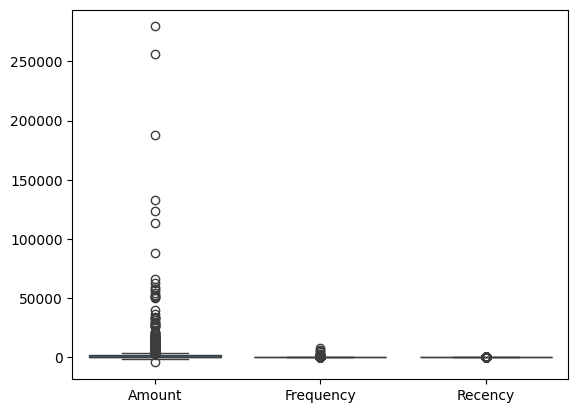

In [74]:
sns.boxplot(grp_df)
plt.show()

In [75]:
#outliers treatment
Q1 = grp_df.Amount.quantile(0.05)
Q3 = grp_df.Amount.quantile(0.95)
IQR = Q3-Q1
grp_df = grp_df[(grp_df.Amount >= Q1-1.5*IQR) &(grp_df.Amount <= Q3+1.5*IQR)]

In [76]:
grp_df.head()

,Amount,Frequency,Recency
CustomerID,,,
12346.0,0.00,2,325
12347.0,4310.00,182,1
12348.0,1797.24,31,74
12349.0,1757.55,73,18
12350.0,334.40,17,309


In [77]:
Q1 = grp_df.Frequency.quantile(0.05)
Q3 = grp_df.Frequency.quantile(0.95)
IQR = Q3-Q1
grp_df = grp_df[(grp_df.Frequency >= Q1-1.5*IQR) &(grp_df.Frequency <= Q3+1.5*IQR)]

In [78]:
grp_df.head()

,Amount,Frequency,Recency
CustomerID,,,
12346.0,0.00,2,325
12347.0,4310.00,182,1
12348.0,1797.24,31,74
12349.0,1757.55,73,18
12350.0,334.40,17,309


In [79]:
Q1 = grp_df.Recency.quantile(0.05)
Q3 = grp_df.Recency.quantile(0.95)
IQR = Q3-Q1
grp_df = grp_df[(grp_df.Recency >= Q1-1.5*IQR) &(grp_df.Recency <= Q3+1.5*IQR)]

In [80]:
grp_df.head()

,Amount,Frequency,Recency
CustomerID,,,
12346.0,0.00,2,325
12347.0,4310.00,182,1
12348.0,1797.24,31,74
12349.0,1757.55,73,18
12350.0,334.40,17,309


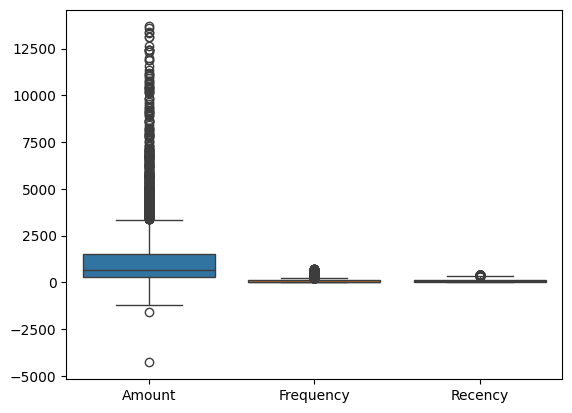

In [81]:
sns.boxplot(grp_df)
plt.show()

In [82]:
rfm = grp_df[['Amount','Frequency','Recency']]
rfm.head()

,Amount,Frequency,Recency
CustomerID,,,
12346.0,0.00,2,325
12347.0,4310.00,182,1
12348.0,1797.24,31,74
12349.0,1757.55,73,18
12350.0,334.40,17,309


In [89]:
scaler =StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled.shape

(4293, 3)

In [90]:
kmeans= KMeans(n_clusters=4,max_iter=50)
kmeans.fit(rfm_scaled)
labels = kmeans.labels_
labels

array([0, 3, 2, ..., 0, 2, 2], dtype=int32)

In [93]:
range_n_clusters = [2,3,4,5,6,7,8]
for num_cluster in range_n_clusters:
  kmeans=KMeans(n_clusters=num_cluster,max_iter=50)
  kmeans.fit(rfm_scaled)
  labels = kmeans.labels_



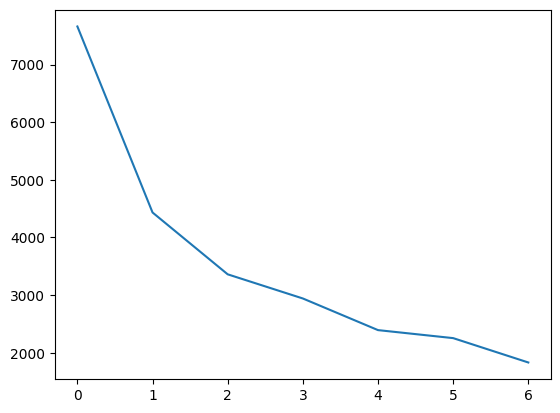

In [102]:
ssd = []
range_n_clusters = [2,3,4,5,6,7,8]
for num_cluster in range_n_clusters:
  kmeans=KMeans(n_clusters=num_cluster,max_iter=50)
  kmeans.fit(rfm_scaled)
  kmeans.labels_
  cluster_ssd = kmeans.inertia_
  ssd.append(cluster_ssd)

plt.plot(ssd)
plt.show()

In [98]:
#silhouette analysis
range_n_clusters = [2,3,4,5,6,7,8]
for num_cluster in range_n_clusters:
  kmeans=KMeans(n_clusters=num_cluster,max_iter=50)
  kmeans.fit(rfm_scaled)
  cluster_labels = kmeans.labels_

  silhouette_avg = silhouette_score(rfm_scaled,cluster_labels)
  print('Silhouette score is {0}. for cluster number is {1}'.format(round(silhouette_avg,2),num_cluster))

Silhouette score is 0.54. for cluster number is 2
Silhouette score is 0.51. for cluster number is 3
Silhouette score is 0.48. for cluster number is 4
Silhouette score is 0.46. for cluster number is 5
Silhouette score is 0.43. for cluster number is 6
Silhouette score is 0.41. for cluster number is 7
Silhouette score is 0.4. for cluster number is 8


In [99]:
kmeans = KMeans(n_clusters=3,max_iter=50)
kmeans.fit(rfm_scaled)
print(kmeans.labels_)

[2 1 0 ... 2 0 0]


In [100]:
grp_df['ClusterID'] = kmeans.labels_
grp_df.head()

,Amount,Frequency,Recency,ClusterID
CustomerID,,,,
12346.0,0.00,2,325,2
12347.0,4310.00,182,1,1
12348.0,1797.24,31,74,0
12349.0,1757.55,73,18,0
12350.0,334.40,17,309,2


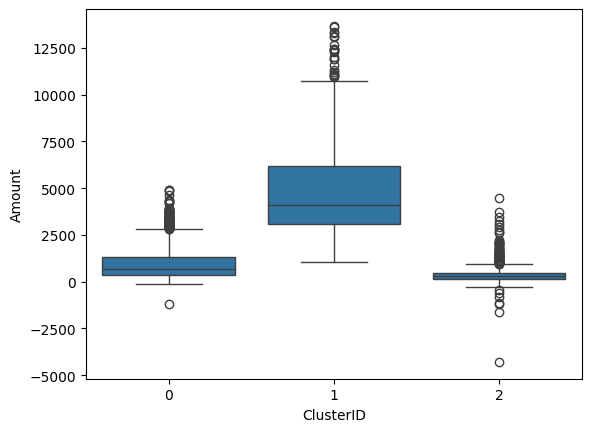

In [103]:
sns.boxplot(x='ClusterID',y='Amount',data=grp_df)
plt.show()

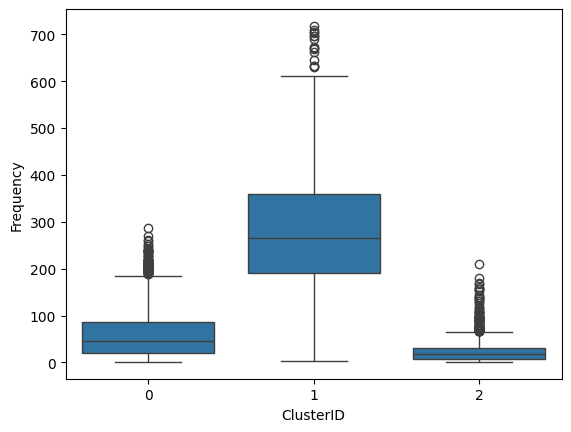

In [104]:
sns.boxplot(x='ClusterID',y='Frequency',data=grp_df)
plt.show()

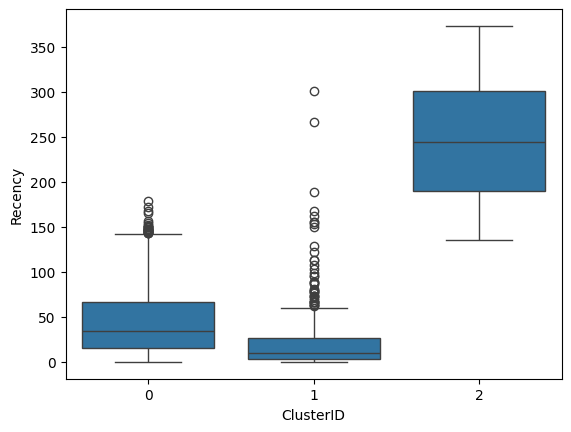

In [105]:
sns.boxplot(x='ClusterID',y='Recency',data=grp_df)
plt.show()

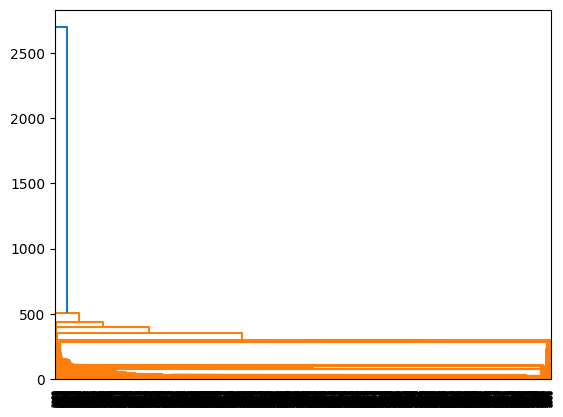

In [106]:
# Hierarchy clustering
mergings =linkage(grp_df,method='single',metric='euclidean')
dendrogram(mergings)
plt.show()

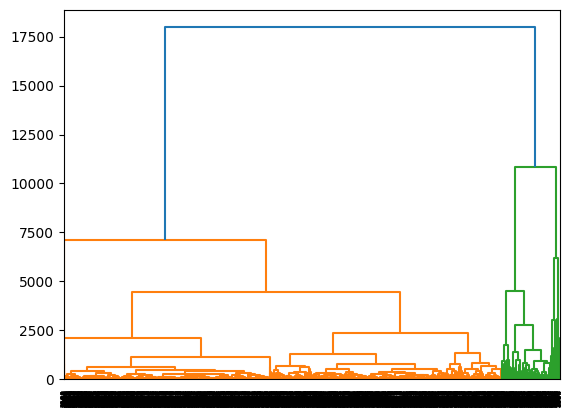

In [107]:
mergings = linkage(grp_df,method='complete',metric='euclidean')
dendrogram(mergings)
plt.show()

In [109]:
cluster_label =cut_tree(mergings,n_clusters=3).reshape(-1,)
cluster_label

array([0, 1, 0, ..., 0, 0, 0])

In [110]:
grp_df['Cluster_Labels'] = cluster_label
grp_df.head()

,Amount,Frequency,Recency,ClusterID,Cluster_Labels
CustomerID,,,,,
12346.0,0.00,2,325,2,0
12347.0,4310.00,182,1,1,1
12348.0,1797.24,31,74,0,0
12349.0,1757.55,73,18,0,0
12350.0,334.40,17,309,2,0


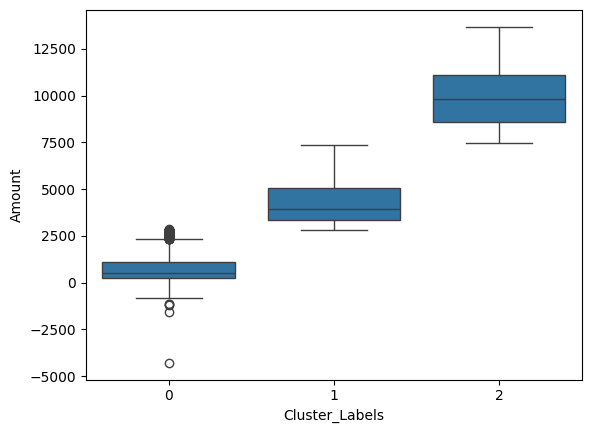

In [111]:
sns.boxplot(x='Cluster_Labels',y='Amount',data=grp_df)
plt.show()

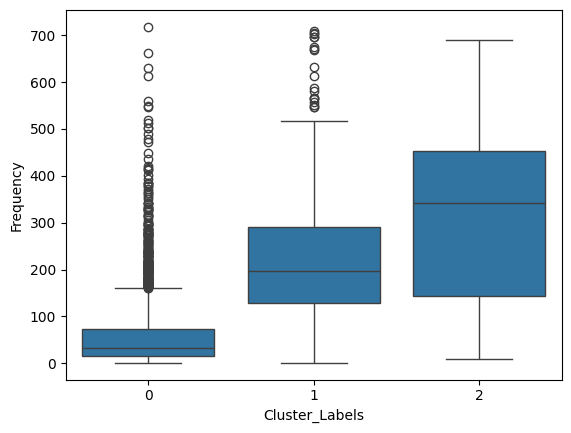

In [112]:
sns.boxplot(x='Cluster_Labels',y='Frequency',data=grp_df)
plt.show()

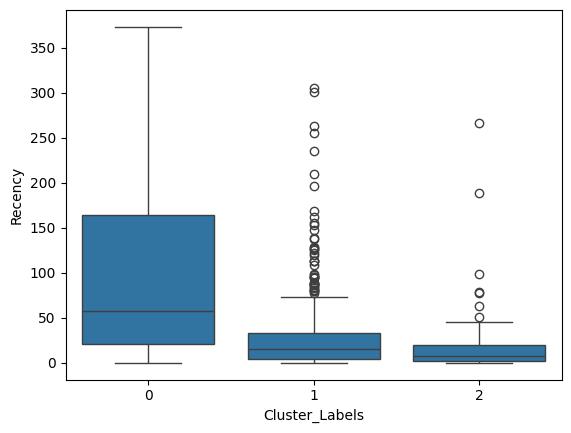

In [113]:
sns.boxplot(x='Cluster_Labels',y='Recency',data=grp_df)
plt.show()